# Feature selection — forecast t+1 (`prod_pet`), set recursion-safe

Notebook de modelado + selección de features para el forecast de petróleo. El orden
es el que tiene sentido metodológico:

1. **Se parte del set recursion-safe**: se excluyen las features que **no** se pueden
   recalcular en un mes futuro a partir de la propia trayectoria del target (§1.1).
2. **Primero se tunean los hiperparámetros** (CV temporal, expanding window) →
   obtenemos un modelo campeón bien ajustado.
3. **Después se hace feature selection** *sobre ese campeón*: se rankean las
   features por *permutation importance* en **val** y se busca el set más chico
   que no pierde RMSE.

**Anti-leakage (ADR-028):** se tunea/entrena en `train`, se rankea y selecciona en
`val` (el mismo set que ya se usa para comparar modelos); **`test` queda intacto**.
Medir la importancia en val (no en train) evita premiar features que el modelo
memorizó pero no generalizan.

La lógica reutilizable vive en `ml/modeling.py` (tuning) y `ml/selection.py`
(selección); acá solo se orquesta.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import pandas as pd

from ml import modeling, selection

pd.set_option("display.width", 120)

## 1. Dataset y matriz de features

`build_feature_matrix` arma el dataset (features del mes `t` + target `y_next` del
mes `t+1`) y devuelve las features **crudas** (el one-hot lo hace el `Pipeline`,
por fold). Features = todas las columnas menos las claves y `y_next`.

In [2]:
ds_enc, feature_cols = modeling.build_feature_matrix()  # target='prod_pet' por defecto

print(f"Filas: {len(ds_enc):,}  |  Features totales: {len(feature_cols)}")
print(ds_enc["split"].value_counts().reindex(["train", "val", "test"]).to_string())

Filas: 319,554  |  Features totales: 40
split
train    223615
val       47883
test      48056


## 1.1 Excluir las features NO recursion-safe

El objetivo de fondo es habilitar el **forecast recursivo** (predecir t+1, t+2, …
realimentando la propia predicción). Para eso, cada feature de un mes futuro tiene
que poder calcularse desde lo único que generamos hacia adelante: **la trayectoria
del propio `prod_pet`** (+ atributos estáticos + calendario). Las que no cumplen esto
se excluyen **antes** de tunear y seleccionar:

| Feature | Por qué NO es recursion-safe |
|---|---|
| `prod_vecinos_mean` | Cross-well: depende de la producción de **otros** pozos en el mes t (que no forecasteamos). |
| `water_cut` | Necesita `prod_agua` del mes futuro, que no forecasteamos. |
| `prod_gas` | Otra serie **medida** del pozo; en el mes futuro no la tenemos. |
| `prod_agua` | Ídem. |
| `tef` | Variable operativa del mes futuro, desconocida al predecir. |

Se **mantiene** `prod_pet` (es el último valor del target = persistencia, se realimenta
con la propia predicción) y sus derivadas autorregresivas (`prod_pet_roll3/delta1/lag12/`
`acum6`, `produjo_mes_pasado`), más las estáticas (`profundidad`, coords, categóricas)
y `mes`. `coordenadax/y` quedan como candidatas (son estáticas → safe); que decida la
selección si aportan sin los vecinos.

In [3]:
# No recursion-safe: no se recalculan en un mes futuro desde la trayectoria del target.
NO_RECURSION_SAFE = [
    "prod_vecinos_mean",  # cross-well: depende de OTROS pozos
    "water_cut",          # depende de prod_agua(t+1)
    "prod_gas",           # otra serie medida del pozo, no la forecasteamos
    "prod_agua",          # idem
    "tef",                # variable operativa del mes futuro, desconocida
]

feature_cols = [c for c in feature_cols if c not in NO_RECURSION_SAFE]
print(f"Excluidas: {NO_RECURSION_SAFE}")
print(f"Features recursion-safe: {len(feature_cols)}")
print(feature_cols)

Excluidas: ['prod_vecinos_mean', 'water_cut', 'prod_gas', 'prod_agua', 'tef']
Features recursion-safe: 35
['prod_pet', 'profundidad', 'coordenadax', 'coordenaday', 'mes', 'prod_pet_roll3', 'prod_pet_delta1', 'prod_pet_lag12', 'prod_pet_acum6', 'produjo_mes_pasado', 'prod_pet_lag2', 'prod_pet_lag3', 'prod_pet_roll6', 'prod_pet_acum12', 'prod_pet_delta3', 'prod_pet_ratio1', 'prod_pet_std3', 'prod_pet_cummax', 'prod_pet_frac_peak', 'prod_pet_meses_desde_pico', 'well_age_months', 'tipoextraccion', 'tipoestado', 'tipopozo', 'empresa', 'formprod', 'formacion', 'areapermisoconcesion', 'areayacimiento', 'cuenca', 'provincia', 'proyecto', 'clasificacion', 'subclasificacion', 'sub_tipo_recurso']


## 2. Split train / val

`X` queda como DataFrame con las columnas crudas; el `Pipeline` se encarga del
one-hot / imputación / escalado ajustando **solo en train**. Guardamos también
`X_train`/`X_val` porque los reusa la feature selection.

In [4]:
X_train, y_train, X_val, y_val = modeling.split_train_val(ds_enc, feature_cols)
print("train:", X_train.shape, " | val:", X_val.shape)

train: (223615, 35)  | val: (47883, 35)


## 3. Búsqueda de hiperparámetros (primero) — CV temporal

`tune_all` corre un **random search** con **CV temporal (expanding window por mes)**:
en cada fold el bloque de validación es posterior a todo su train → sin leakage
futuro→pasado. El preprocesamiento va dentro del `Pipeline`, así que se reajusta
por fold. La búsqueda es **dentro de train**; `val` sigue intacto para la
comparación final. Modelos: **Ridge**, **Random Forest**, **XGBoost**.

> ⚠️ Entrena muchos modelos: puede tardar varios minutos. Cada modelo muestra
> una barra de progreso con el mejor RMSE de CV hasta el momento.

In [5]:
tabla_cv, searches = modeling.tune_all(ds_enc, feature_cols, n_splits=4)
tabla_cv

ridge (20 configs):   0%|          | 0/20 [00:00<?, ?it/s]

random_forest (20 configs):   0%|          | 0/20 [00:00<?, ?it/s]

xgboost (20 configs):   0%|          | 0/20 [00:00<?, ?it/s]

,modelo,cv_rmse,best_params
0,random_forest,214.849077,"{'model__n_estimators': 200, 'model__min_sampl..."
1,xgboost,227.467244,"{'model__subsample': 0.8, 'model__n_estimators..."
2,ridge,8613.483799,{'model__alpha': 10000.0}


### 3.1 Evaluación de los tuneados en val + elección del campeón

Cada `best_estimator_` (reentrenado en todo train con sus mejores hiperparámetros)
se evalúa sobre **val**. Elegimos como **campeón** el de menor `val_rmse` (excluyendo
la persistencia, que es solo la referencia a batir).

In [6]:
comparacion_tuned = modeling.eval_searches_on_val(searches, ds_enc, feature_cols)
comparacion_tuned.round(3)

,modelo,val_rmse,val_r2
0,random_forest,227.762,0.902
1,xgboost,236.932,0.894
2,ridge,238.993,0.892
3,persistencia (baseline),250.589,0.881


In [7]:
nombre_campeon = min(
    searches,
    key=lambda n: modeling.evaluate(y_val, searches[n].best_estimator_.predict(X_val))["val_rmse"],
)
champion = searches[nombre_campeon].best_estimator_
print(f"Campeón (menor val_rmse): {nombre_campeon}")
print("Hiperparámetros:", searches[nombre_campeon].best_params_)

Campeón (menor val_rmse): random_forest
Hiperparámetros: {'model__n_estimators': 200, 'model__min_samples_leaf': 5, 'model__max_features': 0.5, 'model__max_depth': 24}


## 4. Feature selection (sobre el campeón)

### 4.1 Ranking por *permutation importance* en val

Para cada feature se **permuta su columna en val** (`n_repeats` veces) y se mide
cuánto sube el RMSE. Como el `Pipeline` hace el one-hot adentro, se permuta a nivel
de **feature cruda** (p. ej. `empresa` entera, no una categoría suelta).

La importancia queda en **m³** = cuánto empeora el RMSE de val al romper la feature.
**> 0** = útil; **≈ 0 o < 0** = ruido (permutarla no empeora, o hasta mejora).

In [8]:
ranking = selection.permutation_ranking(champion, X_val, y_val, n_repeats=10)
ranking.round(2)

,feature,imp_mean,imp_std
0,prod_pet,461.68,1.85
1,prod_pet_roll3,113.39,0.60
2,prod_pet_ratio1,24.48,1.06
3,prod_pet_acum12,23.92,0.67
4,prod_pet_roll6,23.33,0.21
5,prod_pet_acum6,22.46,0.37
6,areayacimiento,13.85,0.42
7,profundidad,10.24,0.33
8,prod_pet_cummax,4.00,0.15
9,prod_pet_lag2,2.98,0.14


Visualización del ranking (las 20 features más importantes; barra = aumento de
RMSE al permutar, con su desvío entre repeticiones):

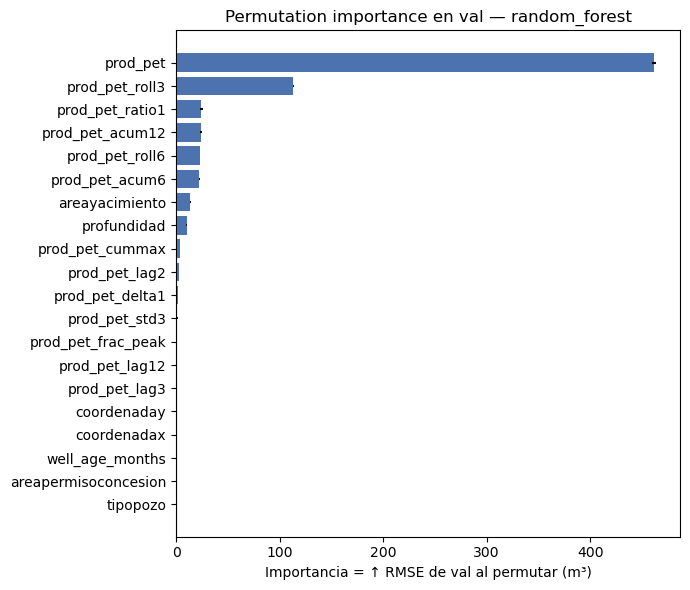

In [9]:
import matplotlib.pyplot as plt

top = ranking.head(20).iloc[::-1]  # la más importante, arriba
fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(top["feature"], top["imp_mean"], xerr=top["imp_std"], color="#4C72B0")
ax.axvline(0, color="0.6", lw=0.8)
ax.set_xlabel("Importancia = ↑ RMSE de val al permutar (m³)")
ax.set_title(f"Permutation importance en val — {nombre_campeon}")
fig.tight_layout()
plt.show()

### 4.2 Curva top-k: RMSE en val según nº de features

Reentrenamos el campeón (mismos hiperparámetros) usando solo las **top-k** features
del ranking. Buscamos la **rodilla**: a partir de cierto `k`, sumar features ya no
baja el RMSE → nos podemos quedar con el set chico.

In [10]:
curva = selection.evaluate_topk(ranking, champion, X_train, y_train, X_val, y_val)
curva.round(3)

,k,val_rmse,val_r2
0,3,251.194,0.881
1,5,232.652,0.898
2,8,235.221,0.896
3,10,233.464,0.897
4,15,230.701,0.900
5,20,228.360,0.902
6,35,227.259,0.903


### 4.3 Set seleccionado y comparación completo vs reducido

`select_features` se queda con las features de importancia **> 0**. Comparamos el
campeón **completo** vs **reducido** (idénticos hiperparámetros) en val: si el RMSE
se mantiene con muchas menos features, la reducción vale la pena (modelo más simple,
más rápido y con menos features que mantener en el feature store).

In [11]:
seleccionadas = selection.select_features(ranking)  # imp_mean > 0
print(f"Seleccionadas ({len(seleccionadas)}/{len(feature_cols)}):")
print(seleccionadas)

Seleccionadas (27/35):
['prod_pet', 'prod_pet_roll3', 'prod_pet_ratio1', 'prod_pet_acum12', 'prod_pet_roll6', 'prod_pet_acum6', 'areayacimiento', 'profundidad', 'prod_pet_cummax', 'prod_pet_lag2', 'prod_pet_delta1', 'prod_pet_std3', 'prod_pet_frac_peak', 'prod_pet_lag12', 'prod_pet_lag3', 'coordenaday', 'coordenadax', 'well_age_months', 'areapermisoconcesion', 'tipopozo', 'empresa', 'prod_pet_meses_desde_pico', 'mes', 'tipoextraccion', 'produjo_mes_pasado', 'proyecto', 'cuenca']


In [12]:
_, m_full = selection.refit_and_eval(champion, feature_cols, X_train, y_train, X_val, y_val)
_, m_red = selection.refit_and_eval(champion, seleccionadas, X_train, y_train, X_val, y_val)

pd.DataFrame([
    {"modelo": f"{nombre_campeon} (completo)", "n_features": len(feature_cols), **m_full},
    {"modelo": f"{nombre_campeon} (reducido)", "n_features": len(seleccionadas), **m_red},
]).round(3)

,modelo,n_features,val_rmse,val_r2
0,random_forest (completo),35,227.259,0.903
1,random_forest (reducido),27,227.531,0.902


## 5. Conclusión / próximos pasos

- Esta corrida ya trabaja sobre el set **recursion-safe** (sin `prod_vecinos_mean`,
  `water_cut`, `prod_gas`, `prod_agua`, `tef`). El ranking te dice cuáles de las que
  **quedan** aportan de verdad.
- Si el modelo **reducido** empata (o casi) al completo recursion-safe, nos quedamos
  con el set chico y lo documentamos en un **ADR** (features finales + criterio de
  selección leakage-safe + baja de las no recursion-safe).
- Opcional pero recomendado: **re-tunear** los hiperparámetros con el set reducido
  (el óptimo puede moverse un poco al cambiar la dimensionalidad).
- **Paso siguiente de feature engineering:** sumar features autorregresivas nuevas
  del propio target (`prod_pet_lag2/lag3`, `slope3`, `ratio1`, `frac_peak`,
  `well_age_months`, …) en `ml/features.py` y volver a correr esta selección sobre
  ese set ampliado. Esta corrida es el primer filtro empírico.